In [15]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

In [16]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [17]:
# train/validation/test = 70/10/20
dataset = pd.read_csv('dataset/ngtdm/kernel5-radius5/dataset.200p.csv')

train_data, temp_data = train_test_split(
    dataset, test_size=0.3, random_state=42
 )
validation_data, test_data = train_test_split(
    temp_data, test_size=2/3, random_state=42
 )

In [18]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

In [19]:
import keras

In [20]:
%%time

# Train a Gradient Boosted Trees model.
model = tfdf.keras.GradientBoostedTreesModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmp2kmcxs8f as temporary training directory
Reading training dataset...


[WARNING 26-05-27 15:55:56.9236 UTC gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 26-05-27 15:55:56.9236 UTC gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 26-05-27 15:55:56.9237 UTC gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:00:00.414782. Found 157360 examples.
Training model...
Model trained in 0:00:17.018093
Compiling model...
Model compiled.
CPU times: user 1min 6s, sys: 1.15 s, total: 1min 7s
Wall time: 17.5 s


[INFO 26-05-27 15:56:14.3514 UTC kernel.cc:1233] Loading model from path /tmp/tmp2kmcxs8f/model/ with prefix aef4e35dd86c47b6
[INFO 26-05-27 15:56:14.3631 UTC quick_scorer_extended.cc:911] The binary was compiled without AVX2 support, but your CPU supports it. Enable it for faster model inference.
[INFO 26-05-27 15:56:14.3639 UTC abstract_model.cc:1362] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 26-05-27 15:56:14.3639 UTC kernel.cc:1061] Use fast generic engine


In [21]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

23/23 [==============================] - 0s 3ms/step - loss: 0.0000e+00 - accuracy: 0.8710

loss: 0.0000
accuracy: 0.8710


In [22]:
# Model Summary
model.summary()

Model: "gradient_boosted_trees_model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (5):
	Busyness
	Coarseness
	Complexity
	Contrast
	Strength

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.   "Busyness"  0.363425 ################
    2.   "Contrast"  0.273164 #####
    3. "Complexity"  0.268397 #####
    4. "Coarseness"  0.248396 ###
    5.   "Strength"  0.220893 

Variable Importance: NUM_AS_ROOT:
    1.   "Busyness" 76.000000 ################
    2.   "Contrast" 59.000000 ############
    3. "Coarseness" 47.000000 #########
    4. "Complexity" 30.000000 #####
    5.   "Strength"  6.000000 

Variable Importance: NUM_NODES:
    1.   

In [23]:
# Model features
model.make_inspector().features()

["Busyness" (1; #0),
 "Coarseness" (1; #1),
 "Complexity" (1; #2),
 "Contrast" (1; #3),
 "Strength" (1; #4)]

In [24]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Busyness" (1; #0), 0.36342526523505314),
  ("Contrast" (1; #3), 0.27316352388210985),
  ("Complexity" (1; #2), 0.2683967264405917),
  ("Coarseness" (1; #1), 0.2483957332276523),
  ("Strength" (1; #4), 0.22089339587924403)],
 'SUM_SCORE': [("Coarseness" (1; #1), 65676.90913881913),
  ("Busyness" (1; #0), 33971.350138634865),
  ("Complexity" (1; #2), 12065.09831723111),
  ("Contrast" (1; #3), 6890.191306497704),
  ("Strength" (1; #4), 6103.198141546324)],
 'NUM_AS_ROOT': [("Busyness" (1; #0), 76.0),
  ("Contrast" (1; #3), 59.0),
  ("Coarseness" (1; #1), 47.0),
  ("Complexity" (1; #2), 30.0),
  ("Strength" (1; #4), 6.0)],
 'NUM_NODES': [("Busyness" (1; #0), 1636.0),
  ("Contrast" (1; #3), 1134.0),
  ("Complexity" (1; #2), 1018.0),
  ("Coarseness" (1; #1), 985.0),
  ("Strength" (1; #4), 972.0)]}

In [25]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=None, accuracy=0.8530169725418091, loss=0.6553768515586853, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

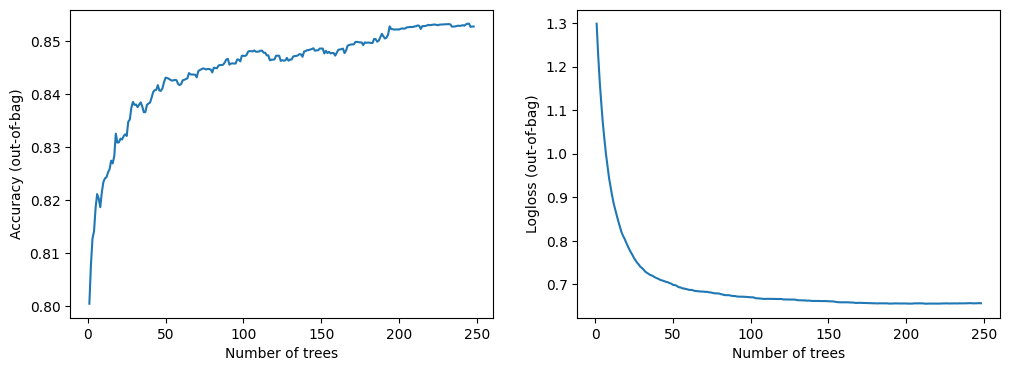

In [26]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [27]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

 1/23 [>.............................] - ETA: 0s

23/23 [==============================] - 0s 3ms/step
The ROC AUC score is 0.92896


In [28]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

45/45 [==============================] - 0s 3ms/step
Sklearn binary metrics:
accuracy: 0.8739
precision: 0.3179
recall: 0.8353
f1: 0.4605
mcc: 0.4660
roc_auc: 0.9328
pr_auc: 0.6248
log_loss: 0.3003
brier_score: 0.0923

Confusion matrix:
 [[36874  5191]
 [  477  2419]]

Classification report:
               precision    recall  f1-score   support

           0     0.9872    0.8766    0.9286     42065
           1     0.3179    0.8353    0.4605      2896

    accuracy                         0.8739     44961
   macro avg     0.6526    0.8559    0.6946     44961
weighted avg     0.9441    0.8739    0.8985     44961

